# Лабораторная работа №4: Линейная регрессия

Выполнил студент группы 6401-010302D Смирнов Андрей Александрович


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly as pl
import sklearn
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

## 1. Считать в `pandas.DataFrame` любой источник данных: CSV, JSON, Excel-файл, HTML-таблицу и т.п.


In [ ]:
df = pd.read_csv("/content/student-mat.csv", delimiter=';')
pd.set_option('display.max_columns', None)

df

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,reason,guardian,traveltime,studytime,failures,schoolsup,famsup,paid,activities,nursery,higher,internet,romantic,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,course,mother,2,2,0,yes,no,no,no,yes,yes,no,no,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,course,father,1,2,0,no,yes,no,no,no,yes,yes,no,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,other,mother,1,2,3,yes,no,yes,no,yes,yes,yes,no,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,home,mother,1,3,0,no,yes,yes,yes,yes,yes,yes,yes,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,home,father,1,2,0,no,yes,yes,no,yes,yes,no,no,4,3,2,1,2,5,4,6,10,10
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
390,MS,M,20,U,LE3,A,2,2,services,services,course,other,1,2,2,no,yes,yes,no,yes,yes,no,no,5,5,4,4,5,4,11,9,9,9
391,MS,M,17,U,LE3,T,3,1,services,services,course,mother,2,1,0,no,no,no,no,no,yes,yes,no,2,4,5,3,4,2,3,14,16,16
392,MS,M,21,R,GT3,T,1,1,other,other,course,other,1,1,3,no,no,no,no,no,yes,no,no,5,5,3,3,3,3,3,10,8,7
393,MS,M,18,R,LE3,T,3,2,services,other,course,mother,3,1,0,no,no,no,no,no,yes,yes,no,4,4,1,3,4,5,0,11,12,10


## 2. Датасет и подготовка данных, этап 1:


- Привести описание датасета



Датасет содержит различные данные об учениках двух школ в Португалии.

Целевые признаки:
- G3 - Оценка по математике за год (0-20)

| Признак | Описание | Тип / Единицы измерения
   | --- | --- | --- |
school | Школа ученика | Категориальный, бинарный: 'GP' / 'MS'
sex | Пол ученика |Категориальный, бинарный: 'F' / 'M'
age | Возраст ученика |Числовой, годы (15–22)
address |Тип места проживания | Категориальный, бинарный: 'U' (город) / 'R' (село)
famsize |Размер семьи |Категориальный, бинарный: 'LE3' (≤3) / 'GT3' (>3)
Pstatus |Статус совместного проживания родителей |Категориальный, бинарный: 'T' (вместе) / 'A' (раздельно)
Medu |Уровень образования матери |Порядковый, шкала 0–4 (0: нет, 1: начальное, 2: 5–9 кл., 3: среднее, 4: высшее)
Fedu |Уровень образования отца | Порядковый, шкала 0–4 (аналогично Medu)
Mjob |Работа матери |Категориальный, номинальный: 'teacher', 'health', 'services', 'at_home', 'other'
Fjob |Работа отца |Категориальный, номинальный (аналогично Mjob)
reason|Причина выбора школы |Категориальный, номинальный: 'home', 'reputation', 'course', 'other'
guardian | Опекун ученика | Категориальный, номинальный: 'mother', 'father', 'other'
traveltime| Время пути от дома до школы | Порядковый, шкала 1–4 (1: <15 мин, 2: 15–30 мин, 3: 30–60 мин, 4: >1 ч)
studytime | Еженедельное время на учёбу | Порядковый, шкала 1–4 (1: <2 ч, 2: 2–5 ч, 3: 5–10 ч, 4: >10 ч)
failures | Количество прошлых неудач (несданных предметов) | Числовой, дискретный: 1, 2, или 4 (если ≥3)
schoolsup | Дополнительная образовательная поддержка от школы | Бинарный: 'yes' / 'no'
famsup | Образовательная поддержка от семьи | Бинарный: 'yes' / 'no'
paid | Дополнительные платные занятия по предмету | Бинарный: 'yes' / 'no'
activities | Участие во внеклассных мероприятиях | Бинарный: 'yes' / 'no'
nursery | Посещение детского сада | Бинарный: 'yes' / 'no'
higher | Планирует ли получать высшее образование | Бинарный: 'yes' / 'no'
internet | Наличие интернета дома | Бинарный: 'yes' / 'no'
romantic | Наличие романтических отношений | Бинарный: 'yes' / 'no'
famrel | Качество семейных отношений | Порядковый, шкала 1–5 (1: очень плохо, 5: отлично)
freetime | Количество свободного времени после школы | Порядковый, шкала 1–5 (1: очень мало, 5: очень много)
goout | Частота встреч с друзьями | Порядковый, шкала 1–5 (1: очень редко, 5: очень часто)
Dalc | Потребление алкоголя в будние дни |Порядковый, шкала 1–5 (1: очень мало, 5: очень много)
Walc | Потребление алкоголя в выходные дни | Порядковый, шкала 1–5 (аналогично Dalc)
health | Текущее состояние здоровья | Порядковый, шкала 1–5 (1: очень плохое, 5: отличное)
absences | Количество пропусков школы | Числовой, счётчик (0–93)



- Осуществить предобработку данных (избавиться от `null`, убрать некоторые признаки и т.п.) &ndash; "подчистить данные".
- Нормализовать численные данные.

In [ ]:
cat_cols = [var for var in df.columns if df[var].dtype == 'object']
df = df.drop(columns=['G1', 'G2']) # Убираем лишние признаки
num_cols = [var for var in df.columns if df[var].dtype != 'object']
num_cols.remove('G3') # Убираем целевой признак, чтобы его не нормировать

In [ ]:
# Нормируем числовые признаки
for col in num_cols:
  df[col] = (df[col] - df[col].mean()) / df[col].std()

df

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,reason,guardian,traveltime,studytime,failures,schoolsup,famsup,paid,activities,nursery,higher,internet,romantic,famrel,freetime,goout,Dalc,Walc,health,absences,G3
0,GP,F,1.021751,U,GT3,A,1.142407,1.358648,at_home,teacher,course,mother,0.791247,-0.042232,-0.449374,yes,no,no,no,yes,yes,no,no,0.062115,-0.235711,0.800464,-0.540014,-1.002518,-0.398784,0.036378,6
1,GP,F,0.238078,U,GT3,T,-1.597982,-1.398197,at_home,other,course,father,-0.642435,-0.042232,-0.449374,no,yes,no,no,no,yes,yes,no,1.177367,-0.235711,-0.097784,-0.540014,-1.002518,-0.398784,-0.213525,6
2,GP,F,-1.329268,U,LE3,T,-1.597982,-1.398197,at_home,other,other,mother,-0.642435,-0.042232,3.584777,yes,no,yes,no,yes,yes,yes,no,0.062115,-0.235711,-0.996032,0.582646,0.550402,-0.398784,0.536185,10
3,GP,F,-1.329268,U,GT3,T,1.142407,-0.479249,health,services,home,mother,-0.642435,1.149321,-0.449374,no,yes,yes,yes,yes,yes,yes,yes,-1.053136,-1.236851,-0.996032,-0.540014,-1.002518,1.039751,-0.463428,15
4,GP,F,-0.545595,U,GT3,T,0.228944,0.439699,other,other,home,father,-0.642435,-0.042232,-0.449374,no,yes,yes,no,yes,yes,no,no,0.062115,-0.235711,-0.996032,-0.540014,-0.226058,1.039751,-0.213525,10
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
390,MS,M,2.589096,U,LE3,A,-0.684519,-0.479249,services,services,course,other,-0.642435,-0.042232,2.240060,no,yes,yes,no,yes,yes,no,no,1.177367,1.766567,0.800464,2.827967,2.103322,0.320484,0.661137,9
391,MS,M,0.238078,U,LE3,T,0.228944,-1.398197,services,services,course,mother,0.791247,-1.233786,-0.449374,no,no,no,no,no,yes,yes,no,-2.168388,0.765428,1.698712,1.705307,1.326862,-1.118051,-0.338477,16
392,MS,M,3.372769,R,GT3,T,-1.597982,-1.398197,other,other,course,other,-0.642435,-1.233786,3.584777,no,no,no,no,no,yes,no,no,1.177367,1.766567,-0.097784,1.705307,0.550402,-0.398784,-0.338477,7
393,MS,M,1.021751,R,LE3,T,0.228944,-0.479249,services,other,course,mother,2.224929,-1.233786,-0.449374,no,no,no,no,no,yes,yes,no,0.062115,0.765428,-1.894280,1.705307,1.326862,1.039751,-0.713332,10


- Разбить выборку на обучающую и тестовую.
     > Из датафреймов обучающей и тестовой выборки необходимо временно убрать категориальные признаки (исходные датафреймы сохранить для 2 этапа).

In [ ]:
y = df['G3']
X = df.drop(columns=['G3'] + cat_cols)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

- Визуализировать `heatmap`-матрицу коррелированности признаков.

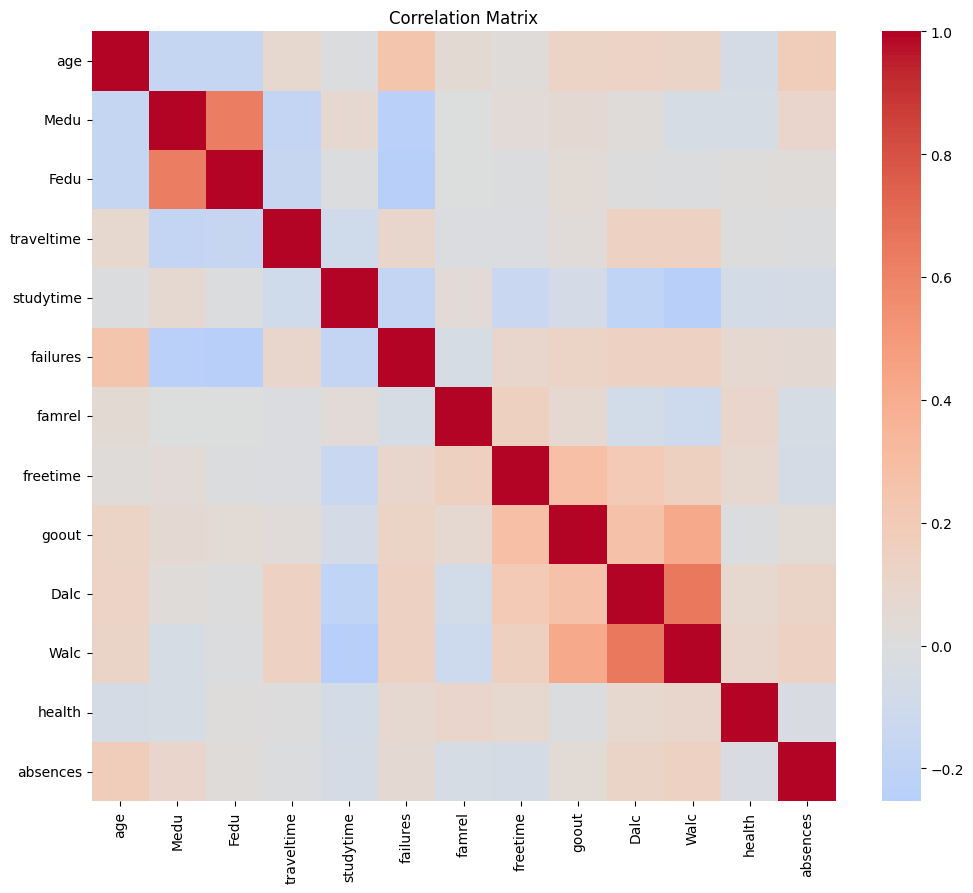

In [ ]:
corr = X.corr()

plt.figure(figsize=(12, 10))
sns.heatmap(corr, cmap='coolwarm', center=0)
plt.title('Correlation Matrix')
plt.show()

- Визуализировать взаимосвязь между `target`-переменной и каждым из признаков (с использованием `srs.pairplot` или `pandas.plotting.scatter_matrix`). Лучше всего построить диаграмму попарного распределения между таргетом и каждым из признаков отдельно (пример с `sns.FacetGrid` в лекции).

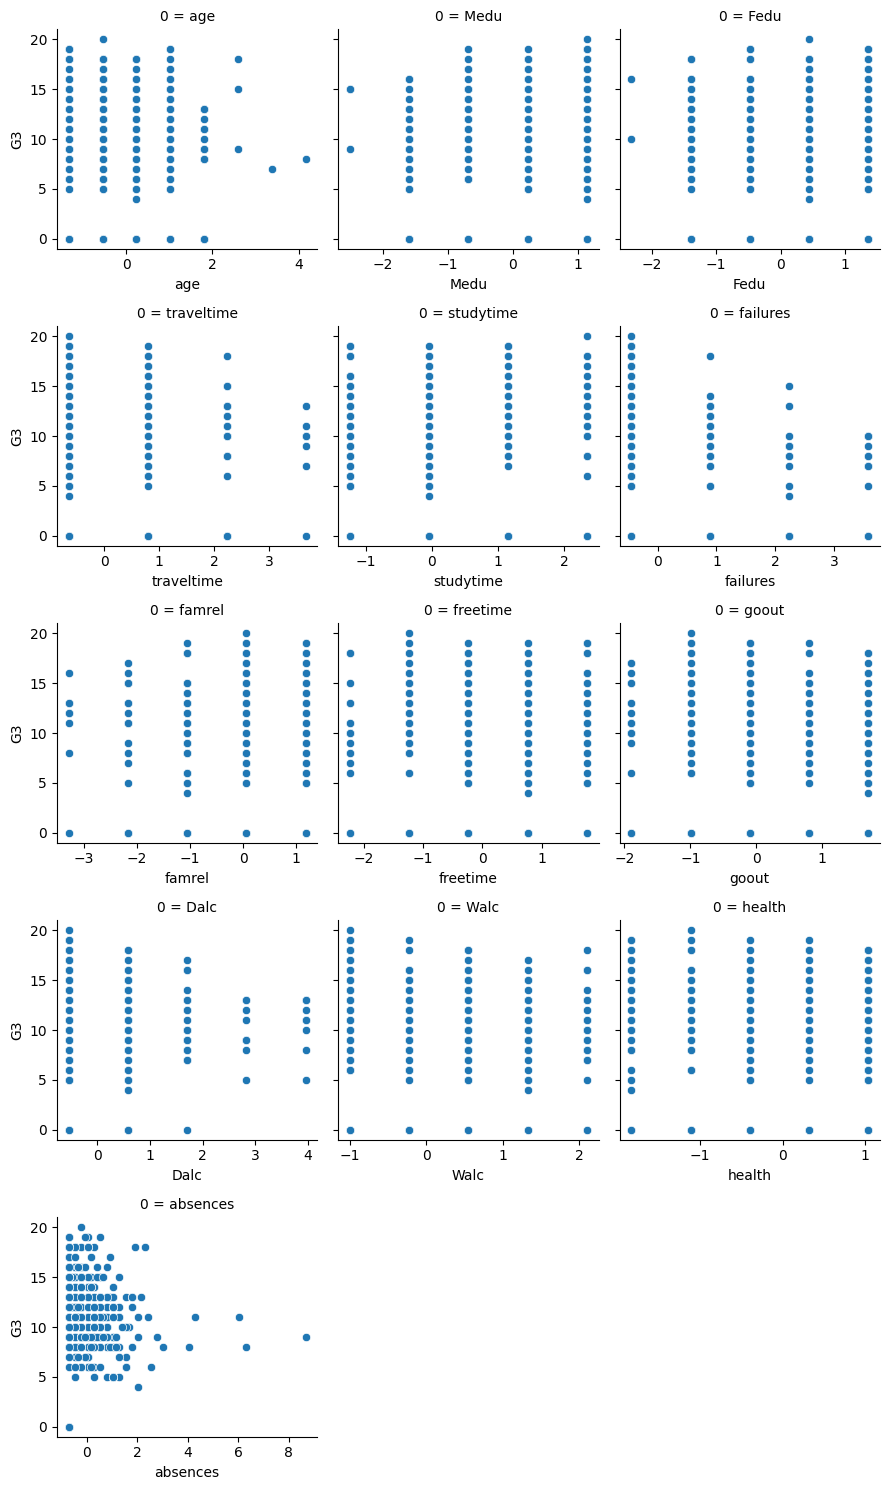

In [ ]:
target = 'G3'
data = df[num_cols + [target]]

fig = sns.FacetGrid(pd.DataFrame(num_cols), col=0, col_wrap=3, sharex=False)

for ax, varx in zip(fig.axes, num_cols):
    sns.scatterplot(data, x=varx, y=target, ax=ax)

fig.tight_layout()


## 3. Регрессия МНК:
   
  
   


- Обучить модель линейной регрессии `LinearRegression`.
 - Вывести метрики $MSE$, $MAE$ и $R^2$ на тестовом наборе.
 - Вывести `model.coef_` и `model.intercept_`.

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Списки для будущей сводной таблицы
best_models = []
MSE= []
MAE = []
R2 = []

linear_model = LinearRegression()

linear_model.fit(X_train, y_train)

y_pred = linear_model.predict(X_test)

best_models.append(linear_model)
MSE.append(mean_squared_error(y_test, y_pred)),
MAE.append(mean_absolute_error(y_test, y_pred))
R2.append(r2_score(y_test, y_pred))
print(f'MSE: {mean_squared_error(y_test, y_pred)}')
print(f'MAE: {mean_absolute_error(y_test, y_pred)}')
print(f'R2: {r2_score(y_test, y_pred)}')
print(f"Model coefficients: {linear_model.coef_}")
print(f"Model intercept: {linear_model.intercept_}")

MSE: 18.089574993693358
MAE: 3.489520715380169
R2: 0.117798912764978
Model coefficients: [-0.33016166  0.68675681 -0.22628813 -0.2415304   0.41763326 -1.44356309
  0.33621664  0.25068788 -0.53409293 -0.04650626  0.31745291 -0.2187519
  0.2938758 ]
Model intercept: 10.347749713840553


  - Построить график (`barh`) с важностью коэффициентов при соответствующих признаках (сверху вниз расположены коэффициенты по убыванию, а названия соответствующих признаков подписаны по вертикальной оси).

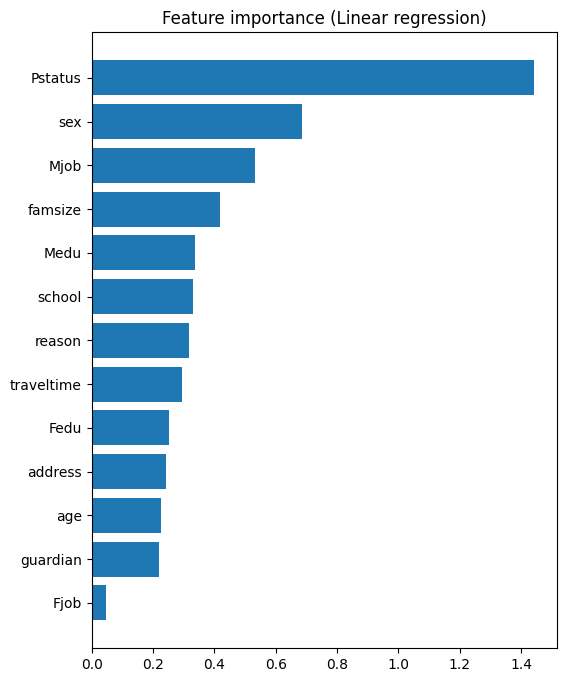

In [ ]:
plt.figure(figsize=(6, 8))
desc_order = np.argsort(abs(linear_model.coef_))
plt.barh(df.drop(columns='G3').columns[desc_order], abs(linear_model.coef_)[desc_order])
plt.title('Feature importance (Linear regression)')
plt.show()

## 4. Для каждого вида регрессии (`Ridge`, `LASSO`, `Elastic Net`, `KNeighborsRegressor` и какой-нибудь tree-based модели регрессии):
   



In [ ]:
from sklearn.linear_model import Ridge, Lasso, ElasticNet
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestRegressor

- С использованием `GridSearchCV` осуществить подбор параметров регуляризации (`alpha` для `Ridge` и `LASSO`, `alpha` и `l1_ratio` для `Elastic Net`) и гиперпараметров (`n_neighbors` для `KNeighborsRegressor`; как минимум `max_depth` для tree-based моделей регрессии).
- Построить график (`barh`) с важностью коэффициентов при соответствующих признаках (сверху вниз расположены коэффициенты по убыванию, а названия соответствующих признаков подписаны по вертикальной оси).  
- Вывести значения гиперпараметров, коэффициенты регрессии (`model.coef_` и `model.intercept_`) и значения метрик на тестовом наборе для наилучшей модели ($MSE$, $MAE$ и $R^2$).


 --- Модель: Ridge(alpha=10) ---
Коэффициенты регрессии: 
coef_: [-0.32745043  0.6523275  -0.18860752 -0.23626163  0.40710066 -1.39889858
  0.32434653  0.23344726 -0.50312639 -0.03791314  0.28203203 -0.21374878
  0.28914175], 
intercept_: 10.346358037923578 

 --- Модель: Lasso(alpha=0.5) ---
Коэффициенты регрессии: 
coef_: [-0.          0.19923473  0.         -0.          0.         -1.17279762
  0.          0.         -0.         -0.         -0.         -0.
  0.        ], 
intercept_: 10.33071013076429 

 --- Модель: ElasticNet(alpha=0.5, l1_ratio=0.9) ---
Коэффициенты регрессии: 
coef_: [-0.          0.24232066  0.         -0.          0.01980621 -1.15182103
  0.          0.         -0.         -0.         -0.         -0.
  0.        ], 
intercept_: 10.330988459365445 


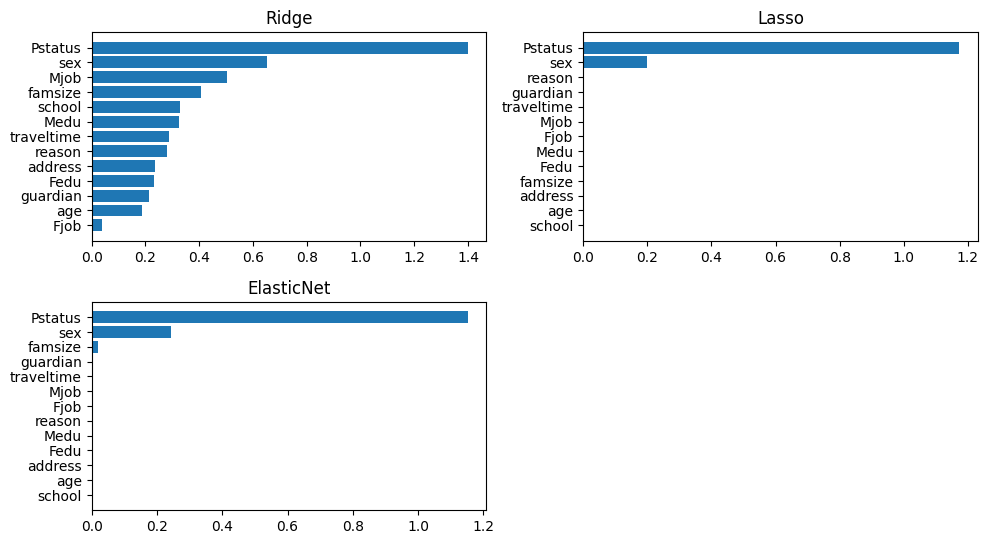

In [ ]:
gridSearchParams = {
    'Ridge':
     {
         'model':Ridge(),
         'params':{'alpha': [0.01, 0.1, 0.5, 1, 10]}
     },
    'Lasso':
    {
        'model':Lasso(),
        'params': {'alpha': [0.01, 0.1, 0.5, 1, 10]}
    },
    'ElasticNet':
     {
         'model':ElasticNet(),
         'params': {'alpha': [0.01, 0.1, 0.5, 1, 10],
                    'l1_ratio':[0.1, 0.3, 0.5, 0.7, 0.9]}
     },
    'KNeighboursRegressor':
     {
        'model':KNeighborsRegressor(),
        'params':{'n_neighbors': np.arange(1, 10, 2)}
     },
    'RandomForestRegressor':
     {
        'model':RandomForestRegressor(),
        'params':{'max_depth': [3, 5, 10, 15], 'n_estimators': [10, 50, 100, 200]}
     }
}

best_params = [None]

plt.figure(figsize=(10, 8))

for id, model_name in enumerate(gridSearchParams.keys()):
  grid = GridSearchCV(
      estimator=gridSearchParams[model_name]['model'],
      param_grid=gridSearchParams[model_name]['params'],
      cv=5,
      scoring='neg_mean_squared_error',
      n_jobs=-1,
  )

  grid.fit(X_train, y_train)
  y_pred = grid.predict(X_test)

  best_models.append(model_name)
  MSE.append(mean_squared_error(y_test, y_pred))
  MAE.append(mean_absolute_error(y_test, y_pred))
  R2.append(r2_score(y_test, y_pred))
  best_params.append(grid.best_params_)

  if hasattr(grid.best_estimator_, 'coef_'):
    print(f'\n --- Модель: {grid.best_estimator_} ---')
    print(f"Коэффициенты регрессии: \ncoef_: {grid.best_estimator_.coef_}, \nintercept_: {grid.best_estimator_.intercept_} ")
    desc_order = np.argsort(abs(grid.best_estimator_.coef_))
    plt.subplot(3,2, id+1)
    plt.barh(df.drop(columns='G3').columns[desc_order], abs(grid.best_estimator_.coef_)[desc_order])
    plt.title(f'{model_name}')

plt.tight_layout()
plt.show()

In [ ]:
# Сводная таблица с лучшими моделями
results = pd.DataFrame({'Модель с лучшими параметрами':best_models,
                        'Лучшие параметры:': best_params,
                        'MSE': MSE,
                        'MAE': MAE,
                        'R2': R2})
results

,Модель с лучшими параметрами,Лучшие параметры:,MSE,MAE,R2
0,LinearRegression(),None,18.089575,3.489521,0.117799
1,Ridge,{'alpha': 10},18.054904,3.484517,0.119490
2,Lasso,{'alpha': 0.5},18.473567,3.437672,0.099072
3,ElasticNet,"{'alpha': 0.5, 'l1_ratio': 0.9}",18.460535,3.436665,0.099708
4,KNeighboursRegressor,{'n_neighbors': 7},16.996900,3.383363,0.171087
5,RandomForestRegressor,"{'max_depth': 5, 'n_estimators': 200}",16.672743,3.296462,0.186896


**Замечание**: RandomForestRegressor по своей природе случаен, из-за чего лучшие параметры для него могут меняться от запуска к запуску.

## 5. Датасет и подготовка данных, этап 2:
   - Использовать датафреймы после разбиения на обучающую и тестовую выборки из 1 этапа с категориальными признаками.
   - Закодировать категориальные признаки в обучающей и тестовой выборках.

In [ ]:
# Определяем бинарные и небинарные категориальные признаки
len_max = max([len(col) for col in cat_cols])
for col in cat_cols:
    print(f"{col:<{len_max}} labels: {len(df[col].unique())}")

school     labels: 2
sex        labels: 2
address    labels: 2
famsize    labels: 2
Pstatus    labels: 2
Mjob       labels: 5
Fjob       labels: 5
reason     labels: 4
guardian   labels: 3
schoolsup  labels: 2
famsup     labels: 2
paid       labels: 2
activities labels: 2
nursery    labels: 2
higher     labels: 2
internet   labels: 2
romantic   labels: 2


In [ ]:
# Кодируем бинарные категориальные признаки
for col in ['schoolsup', 'famsup', 'paid', 'activities', 'nursery', 'higher', 'internet', 'romantic']:
  df[col] = df[col].map({'no':0, 'yes':1})

for col in num_cols:
  df[col] = (df[col] - df[col].mean()) / df[col].std()

df['sex'] = df['sex'].map({'M':0, "F":1})
df['school'] = df['school'].map({'GP':0, "MS":1})
df['address'] = df['address'].map({'U':0, "R":1})
df['famsize'] = df['famsize'].map({'GT3':0, "LE3":1})
df['Pstatus'] = df['Pstatus'].map({'A':0, "T":1})

# Кодируем небинарные категориальные признаки
for col in cat_cols:
    if len(df[col].unique()) > 2:
      dummies = pd.get_dummies(df[col], prefix=col)
      df = df.drop(col, axis=1)
      df = df.join(dummies)

df

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,traveltime,studytime,failures,schoolsup,famsup,paid,activities,nursery,higher,internet,romantic,famrel,freetime,goout,Dalc,Walc,health,absences,G3,Mjob_at_home,Mjob_health,Mjob_other,Mjob_services,Mjob_teacher,Fjob_at_home,Fjob_health,Fjob_other,Fjob_services,Fjob_teacher,reason_course,reason_home,reason_other,reason_reputation,guardian_father,guardian_mother,guardian_other
0,0,1,1.021751,0,0,0,1.142407,1.358648,0.791247,-0.042232,-0.449374,1,0,0,0,1,1,0,0,0.062115,-0.235711,0.800464,-0.540014,-1.002518,-0.398784,0.036378,6,True,False,False,False,False,False,False,False,False,True,True,False,False,False,False,True,False
1,0,1,0.238078,0,0,1,-1.597982,-1.398197,-0.642435,-0.042232,-0.449374,0,1,0,0,0,1,1,0,1.177367,-0.235711,-0.097784,-0.540014,-1.002518,-0.398784,-0.213525,6,True,False,False,False,False,False,False,True,False,False,True,False,False,False,True,False,False
2,0,1,-1.329268,0,1,1,-1.597982,-1.398197,-0.642435,-0.042232,3.584777,1,0,1,0,1,1,1,0,0.062115,-0.235711,-0.996032,0.582646,0.550402,-0.398784,0.536185,10,True,False,False,False,False,False,False,True,False,False,False,False,True,False,False,True,False
3,0,1,-1.329268,0,0,1,1.142407,-0.479249,-0.642435,1.149321,-0.449374,0,1,1,1,1,1,1,1,-1.053136,-1.236851,-0.996032,-0.540014,-1.002518,1.039751,-0.463428,15,False,True,False,False,False,False,False,False,True,False,False,True,False,False,False,True,False
4,0,1,-0.545595,0,0,1,0.228944,0.439699,-0.642435,-0.042232,-0.449374,0,1,1,0,1,1,0,0,0.062115,-0.235711,-0.996032,-0.540014,-0.226058,1.039751,-0.213525,10,False,False,True,False,False,False,False,True,False,False,False,True,False,False,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
390,1,0,2.589096,0,1,0,-0.684519,-0.479249,-0.642435,-0.042232,2.240060,0,1,1,0,1,1,0,0,1.177367,1.766567,0.800464,2.827967,2.103322,0.320484,0.661137,9,False,False,False,True,False,False,False,False,True,False,True,False,False,False,False,False,True
391,1,0,0.238078,0,1,1,0.228944,-1.398197,0.791247,-1.233786,-0.449374,0,0,0,0,0,1,1,0,-2.168388,0.765428,1.698712,1.705307,1.326862,-1.118051,-0.338477,16,False,False,False,True,False,False,False,False,True,False,True,False,False,False,False,True,False
392,1,0,3.372769,1,0,1,-1.597982,-1.398197,-0.642435,-1.233786,3.584777,0,0,0,0,0,1,0,0,1.177367,1.766567,-0.097784,1.705307,0.550402,-0.398784,-0.338477,7,False,False,True,False,False,False,False,True,False,False,True,False,False,False,False,False,True
393,1,0,1.021751,1,1,1,0.228944,-0.479249,2.224929,-1.233786,-0.449374,0,0,0,0,0,1,1,0,0.062115,0.765428,-1.894280,1.705307,1.326862,1.039751,-0.713332,10,False,False,False,True,False,False,False,True,False,False,True,False,False,False,False,True,False


In [ ]:
## Создаем обучающую и тестовую выборки со всеми признаками
y_cat = df['G3']
X_cat = df.drop(columns='G3')

X_cat_train, X_cat_test, y_cat_train, y_cat_test = train_test_split(X_cat, y_cat, test_size=0.2, random_state=42)

## 6. Регрессии, этап 2:

  
   

  


 - Вывести значения гиперпараметров, коэффициенты регрессии (`model.coef_` и `model.intercept_`) и значения метрик на тестовом наборе ($MSE$, $MAE$ и $R^2$).

In [ ]:
# Модели с лучшими параметрами
models = {'LinearRegression':LinearRegression(),
          'Ridge':Ridge(alpha=10),
          'Lasso':Lasso(alpha=0.5),
          'ElasticNet':ElasticNet(alpha=0.5, l1_ratio=0.9),
          'KNeighborsRegressor':KNeighborsRegressor(n_neighbors=7),
          'RandomForestRegressor':RandomForestRegressor(n_estimators=200, max_depth=3)
          }

trained_models = []
MSE_cat = []
MAE_cat = []
R2_cat = []

for model_name, model in models.items():
  model.fit(X_cat_train, y_cat_train)
  y_pred = model.predict(X_cat_test)

  trained_models.append(model)
  MSE_cat.append(mean_squared_error(y_cat_test, y_pred))
  MAE_cat.append(mean_absolute_error(y_cat_test, y_pred))
  R2_cat.append(r2_score(y_cat_test, y_pred))

  # Коэффициенты регрессии (где есть)
  if hasattr(model, 'coef_'):
    print(f'\nМодель: {model}')
    print(f"Коэффициенты регрессии: \ncoef_: {model.coef_}, \nintercept_: {model.intercept_} ")



Модель: LinearRegression()
Коэффициенты регрессии: 
coef_: [ 0.72639203 -1.49591062 -0.47956083 -0.34371505  0.69637301 -0.6451135
  0.51125857 -0.16297929 -0.1833947   0.63584423 -1.37880792 -0.91546997
 -1.25643227  0.77030636 -0.63636126 -0.30972184  1.75088016  0.72183611
 -1.01616685  0.26304139  0.24892879 -0.46546229 -0.12923557  0.05415741
 -0.20377792  0.53069428 -0.08399294  1.03832863 -0.3517108   0.58983843
 -1.19246331 -0.04803956  0.09719036 -0.47847015 -0.46262583  0.89194517
 -0.09399114 -0.48790823  0.30823272  0.27366665 -0.40092864 -0.16339343
  0.56432207], 
intercept_: 11.327788296084377 

Модель: Ridge(alpha=10)
Коэффициенты регрессии: 
coef_: [ 0.50370263 -1.18294912 -0.43468504 -0.2594385   0.59003896 -0.52311176
  0.48091571 -0.10335435 -0.17234126  0.5873627  -1.35860352 -0.69835821
 -1.07598383  0.68337472 -0.5393841  -0.24718974  1.03046389  0.55619041
 -0.8622364   0.25664802  0.23395091 -0.44835665 -0.09872282  0.05268094
 -0.2027433   0.4686412  -0.18895

In [ ]:
# Сравнительная таблица моделей
results = pd.DataFrame({'Модель':best_models,
                        'Параметры:': best_params,
                        'MSE': MSE_cat,
                        'MAE': MAE_cat,
                        'R2': R2_cat})

results

,Модель,Параметры:,MSE,MAE,R2
0,LinearRegression(),None,17.603737,3.395261,0.141492
1,Ridge,{'alpha': 10},17.331546,3.358361,0.154767
2,Lasso,{'alpha': 0.5},18.473567,3.437672,0.099072
3,ElasticNet,"{'alpha': 0.5, 'l1_ratio': 0.9}",18.460535,3.436665,0.099708
4,KNeighboursRegressor,{'n_neighbors': 7},20.060708,3.603978,0.021670
5,RandomForestRegressor,"{'max_depth': 5, 'n_estimators': 200}",16.935762,3.305273,0.174069


In [ ]:
# Сравнительная таблица результатов на датасете с категориальными признаками и без них
results = pd.DataFrame({'Model': models.keys(),
                        'MSE': MSE,
                        'MSE_cat':MSE_cat,
                        "MAE": MAE,
                        'MAE_cat':MAE_cat,
                        "R2": R2,
                        'R2_cat':R2_cat
                        })

results

,Model,MSE,MSE_cat,MAE,MAE_cat,R2,R2_cat
0,LinearRegression,18.089575,17.603737,3.489521,3.395261,0.117799,0.141492
1,Ridge,18.054904,17.331546,3.484517,3.358361,0.119490,0.154767
2,Lasso,18.473567,18.473567,3.437672,3.437672,0.099072,0.099072
3,ElasticNet,18.460535,18.460535,3.436665,3.436665,0.099708,0.099708
4,KNeighborsRegressor,16.996900,20.060708,3.383363,3.603978,0.171087,0.021670
5,RandomForestRegressor,16.672743,16.935762,3.296462,3.305273,0.186896,0.174069


- Сравнить метрики с наличием категориальных признаков и без для каждой из моделей.
- Выбрать лучшую модель.


**Сравнение метрик**:

- `LinearRegression`. При добавлении категориальных признаков все показатели улучшились - понизились $MSE$ и $MAE$, увеличился $R2$
- `Ridge`. При добавлении категориальных признаков все показатели улучшились - понизились $MSE$ и $MAE$, увеличился $R2$
- `Lasso`. При добавлении категориальных признаков результат классификации совсем не изменился. Это связано с тем, что модель зануляет практически все признаки, как мы видели ранее на графиках, и новые признаки тоже оказываются зануленными.
- `ElasticNet`. При добавлении категориальных признаков результат классификации совсем не изменился. Это связано с тем, что модель зануляет практически все признаки, как мы видели ранее на графиках, и новые признаки тоже оказываются зануленными.
- `KNeighborsRegressor`. При добавлении категориальных признаков все показатели ухудшились - повысились $MSE$ и $MAE$, упал $R2$. Можно сделать вывод, что большое число категориальных признаков плохо работает для методов, в основе которых лежит расчет расстояния.
- `RandomForestRegressor`. При добавлении категориальных признаков все показатели улучшились - понизились $MSE$ и $MAE$, увеличился $R2$

**Лучшая модель**:
- Лучшей по показателям $MSE$, $MAE$ и $R^2$ как при использовании категориальных признаков, так и без них, оказалась модель **RandomForestRegressor**.



- Осуществить фильтрацию признаков:
     + с использованием `Recursive Feature Elimination` или [RFECV](https://scikit-learn.org/stable/modules/generated/sklearn.feature_selection.RFECV.html) (`RFE` с кросс-валидацией)
     + с использованием `Sequential Feature Selector` (`forward` или `backward` в зависимости от количества признаков или по желанию)
     + с использованием любой другой процедуры по желанию

- Выбрать лучшую процедуру фильтрации.

In [ ]:
from sklearn.feature_selection import SequentialFeatureSelector, RFE


sfs = SequentialFeatureSelector(estimator=LinearRegression(), n_features_to_select=10, direction='forward')

rfe = RFE(estimator=LinearRegression(), n_features_to_select=10, step=5)

sfs.fit(X_cat_train, y_cat_train)
rfe.fit(X_cat_train, y_cat_train)

sfs_cols = np.array(X_cat.columns[sfs.get_support()])
rfe_cols = np.array(X_cat.columns[rfe.get_support()])

print(f'Отобранные SFS признаки: {sfs_cols}')
print(f'Отобранные RFE признаки: {rfe_cols}')

Отобранные SFS признаки: ['sex' 'Pstatus' 'Medu' 'studytime' 'failures' 'famsup' 'paid' 'romantic'
 'Walc' 'Mjob_teacher']
Отобранные RFE признаки: ['sex' 'failures' 'famsup' 'activities' 'higher' 'internet' 'romantic'
 'Mjob_health' 'Mjob_services' 'reason_other']


In [ ]:
# Отбор признаков путем исключения и оценки падения качества

cols = X_cat.columns

model = LinearRegression()

model.fit(X_cat_train, y_cat_train)
y_pred = model.predict(X_cat_test)

mse = mean_squared_error(y_cat_test, y_pred)

MSE_part = []

for col in cols:
  model.fit(X_cat_train.drop(columns=col), y_cat_train)
  y_pred_part = model.predict(X_cat_test.drop(columns=col))
  MSE_part.append(mean_squared_error(y_cat_test, y_pred_part))


feature_MSE = pd.DataFrame({'Feature':cols, 'MSE_full':mse, 'MSE_partial': MSE_part})
feature_MSE['MSE_change'] = feature_MSE['MSE_full'] - feature_MSE['MSE_partial']

feature_MSE = feature_MSE.sort_values(by='MSE_change', ascending=True)
loo_cols = np.array(feature_MSE.head(10)['Feature'])
print(f'Отобранные признаки: {loo_cols}')
feature_MSE

Отобранные признаки: ['goout' 'romantic' 'schoolsup' 'failures' 'freetime' 'famsize' 'address'
 'age' 'Medu' 'school']


,Feature,MSE_full,MSE_partial,MSE_change
21,goout,17.603737,18.518946,-9.152090e-01
18,romantic,17.603737,18.162892,-5.591545e-01
11,schoolsup,17.603737,18.133021,-5.292835e-01
10,failures,17.603737,17.979529,-3.757916e-01
20,freetime,17.603737,17.767747,-1.640100e-01
4,famsize,17.603737,17.753974,-1.502370e-01
3,address,17.603737,17.732438,-1.287003e-01
2,age,17.603737,17.719280,-1.155425e-01
6,Medu,17.603737,17.708447,-1.047100e-01
0,school,17.603737,17.692137,-8.839964e-02


In [ ]:
model = LinearRegression()

selected_cols = {
    'SFS':sfs_cols,
    'RFE':rfe_cols,
    'LOO':loo_cols
}

for method, cols in selected_cols.items():
  print(f"\n--- Метод: {method} ---")
  model.fit(X_cat_train[cols], y_cat_train)
  y_pred = model.predict(X_cat_test[cols])
  print(f"MSE: {mean_squared_error(y_cat_test, y_pred):.4f}")
  print(f"MAE: {mean_absolute_error(y_cat_test, y_pred):.4f}")
  print(f"R2: {r2_score(y_cat_test, y_pred):.4f}")



--- Метод: SFS ---
MSE: 19.8006
MAE: 3.5472
R2: 0.0344

--- Метод: RFE ---
MSE: 18.2359
MAE: 3.4146
R2: 0.1107

--- Метод: LOO ---
MSE: 16.0778
MAE: 3.1604
R2: 0.2159


**Выводы по процедурам фильтрации признаков**:
  
  Лучший результат дал метод исключения признаков по одному
  и замер падения качества классификации (*Left-one-out*), реализованный вручную

  Как видно, результат классификации на отобранных данным методом признаках лучше по всем показателям ($MSE, MAE, R^2$)

   - Построить график (`barh`) с важностью коэффициентов при соответствующих признаках (сверху вниз расположены коэффициенты по убыванию, а названия соответствующих признаков подписаны по вертикальной оси).

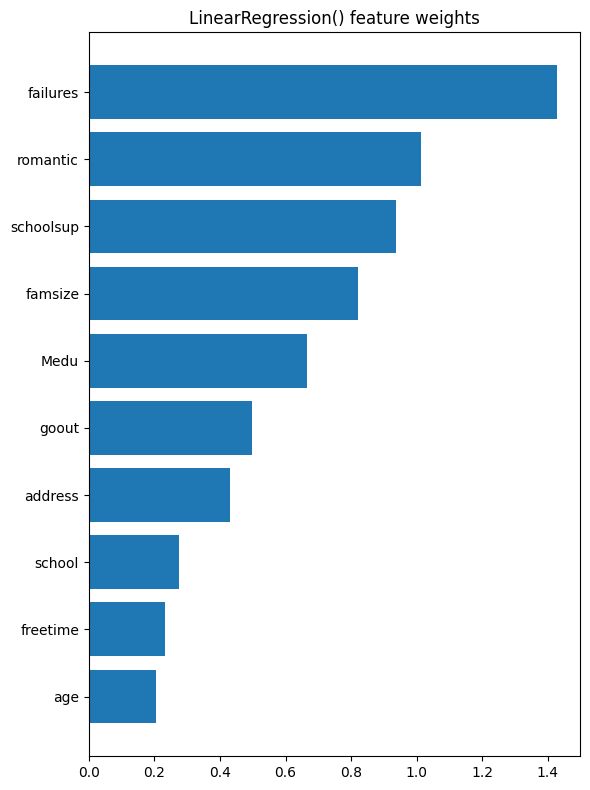

In [ ]:
# График весов отобранных признаков

model = LinearRegression()

model.fit(X_cat_train[loo_cols], y_cat_train)

y_pred = model.predict(X_cat_test[loo_cols])


plt.figure(figsize=(6,8))
desc_order = np.argsort(abs(model.coef_))
plt.barh(loo_cols[desc_order], abs(model.coef_)[desc_order])
plt.title(f'{model} feature weights')

plt.tight_layout()
plt.show()

   - Вывести значения метрик на тестовом наборе ($MSE$, $MAE$ и $R^2$).

In [ ]:
model = RandomForestRegressor(max_depth=5, n_estimators=200)

model.fit(X_cat_train[loo_cols], y_cat_train)

y_pred = model.predict(X_cat_test[loo_cols])

print(f"--- Показатели лучшей модели {model} на отобранных признаках ---")
print(f"MSE: {mean_squared_error(y_cat_test, y_pred):.4f}")
print(f"MAE: {mean_absolute_error(y_cat_test, y_pred):.4f}")
print(f"R2: {r2_score(y_cat_test, y_pred):.4f}")

--- Показатели лучшей модели RandomForestRegressor(max_depth=5, n_estimators=200) на отобранных признаках ---
MSE: 16.3171
MAE: 3.2365
R2: 0.2042


7. Сделать вывод:
   - Лучший регрессор, обученный на данных без категориальных признаков (значения метрик на тестовом наборе).
   - Лучший регрессор, обученный на данных с категориальными признаками (значения метрик на тестовом наборе).
   - Вывод о результатах использования процедуры фильтрации признаков (лучше или хуже &ndash; значения метрик).

## **Выводы**:

### **Модели**

- Лучшей по показателям $MSE$, $MAE$ и $R^2$ как при использовании категориальных признаков, так и без них, оказалась модель **RandomForestRegressor**.

Показатели лучшей модели:
| Показатель | Полный датасет | Без категориальных признаков |  
   | --- | --- | --- |
$MSE$ | 16.6727 | 16.9357
$MAE$ | 3.3052  | 3.2964  
$R^2$ | 0.1740  | 0.1868


---

### **Фильтрация признаков**

На практике было показано, что процедура фильтрации признаков позволяет улучшить результаты классификации.

Лучшей методикой фильтрации оказалась  `Left-one-out`.

 - Для модели `RandomForestRegressor` показатели улучшились следующим образом:

   - $MSE$: 16,6727 -> 16,3171
   - $MAE$: 3,3052 -> 3,2365
   - $R^2$: 0,1740 -> 0,2042

 - Для модели `LinearRegression` показатели улучшились следующим образом:

     - $MSE$: 17,6037 -> 16,0778
     - $MAE$: 3,3952 -> 3,1604
     - $R^2$: 0,1414 -> 0,2159
